In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv 
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [2]:
df = read_csv("../../datasets/heart-disease.csv")
df.head(5)

,age,sex,chest pain type,resting blood presure,serum cholestoral,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,ST depression induced by exercise relative to rest,the slope of the peak exercise ST segment,number of major vessels (0-3) colored by flourosopy,thal,diagnosis of heart disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [3]:
df.isnull().any()

age                                                    False
sex                                                    False
chest pain type                                        False
resting blood presure                                  False
serum cholestoral                                      False
fasting blood sugar > 120 mg/dl                        False
resting electrocardiographic results                   False
maximum heart rate achieved                            False
exercise induced angina                                False
ST depression induced by exercise relative to rest     False
the slope of the peak exercise ST segment              False
number of major vessels (0-3) colored by flourosopy    False
thal                                                   False
diagnosis of heart disease                             False
dtype: bool

In [4]:
df.shape

(303, 14)

In [5]:
index_to_delete = []

for i in range(df.shape[0]):
    for j in range(14):
        if str(df.iloc[i].iloc[j]) == '?':
            print("found non numeric value in %ith column and %ith row"%(i, j))
            index_to_delete.append(i)
            
ndf = df.drop(index=index_to_delete).reset_index()

ndf

found non numeric value in 87th column and 12th row
found non numeric value in 166th column and 11th row
found non numeric value in 192th column and 11th row
found non numeric value in 266th column and 12th row
found non numeric value in 287th column and 11th row
found non numeric value in 302th column and 11th row


,index,age,sex,chest pain type,resting blood presure,serum cholestoral,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,ST depression induced by exercise relative to rest,the slope of the peak exercise ST segment,number of major vessels (0-3) colored by flourosopy,thal,diagnosis of heart disease
0,0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,297,57,0,4,140,241,0,0,123,1,0.2,2,0,7,1
293,298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
294,299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,1
295,300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,1


In [6]:
ndf.columns

Index(['index', 'age', 'sex', 'chest pain type', 'resting blood presure',
       'serum cholestoral', 'fasting blood sugar > 120 mg/dl',
       'resting electrocardiographic results', 'maximum heart rate achieved',
       'exercise induced angina',
       'ST depression induced by exercise relative to rest',
       'the slope of the peak exercise ST segment',
       'number of major vessels (0-3) colored by flourosopy', 'thal',
       'diagnosis of heart disease'],
      dtype='object')

In [7]:
X = ndf[['age', 'sex', 'chest pain type', 'resting blood presure',
       'serum cholestoral', 'fasting blood sugar > 120 mg/dl',
       'resting electrocardiographic results', 'maximum heart rate achieved',
       'exercise induced angina',
       'ST depression induced by exercise relative to rest',
       'the slope of the peak exercise ST segment',
       'number of major vessels (0-3) colored by flourosopy', 'thal']].values
X[0:5]

array([[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, '0', '6'],
       [67, 1, 4, 160, 286, 0, 2, 108, 1, 1.5, 2, '3', '3'],
       [67, 1, 4, 120, 229, 0, 2, 129, 1, 2.6, 2, '2', '7'],
       [37, 1, 3, 130, 250, 0, 0, 187, 0, 3.5, 3, '0', '3'],
       [41, 0, 2, 130, 204, 0, 2, 172, 0, 1.4, 1, '0', '3']], dtype=object)

In [8]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X)
X[0:5]

array([[ 0.93618065,  0.69109474, -2.24062879,  0.75038004, -0.27644339,
         2.43042728,  1.01019851,  0.01749443, -0.69641941,  1.06896529,
         2.26414539, -0.72197605,  0.65587737],
       [ 1.3789285 ,  0.69109474,  0.87388018,  1.59626645,  0.74455507,
        -0.41145029,  1.01019851, -1.81633388,  1.43591632,  0.38177332,
         0.6437811 ,  2.47842525, -0.89422007],
       [ 1.3789285 ,  0.69109474,  0.87388018, -0.65943064, -0.35349988,
        -0.41145029,  1.01019851, -0.89941972,  1.43591632,  1.32666228,
         0.6437811 ,  1.41162482,  1.17257652],
       [-1.94168041,  0.69109474, -0.16428947, -0.09550637,  0.05104668,
        -0.41145029, -1.00341866,  1.63300986, -0.69641941,  2.09975324,
         2.26414539, -0.72197605, -0.89422007],
       [-1.49893255, -1.44697961, -1.20245913, -0.09550637, -0.83510292,
        -0.41145029,  1.01019851,  0.97807117, -0.69641941,  0.29587432,
        -0.97658319, -0.72197605, -0.89422007]])

In [9]:
Y = ndf['diagnosis of heart disease'].values
Y[0:5]

array([0, 1, 1, 0, 0], dtype=int64)

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=4)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)

training data:  (207, 13) (207,)
testing data:  (90, 13) (90,)


In [11]:
x_test.shape

(90, 13)

In [17]:
diseaseTree = DecisionTreeClassifier(criterion='entropy', max_depth=30)
diseaseTree.fit(x_train, y_train)
diseaseTree

DecisionTreeClassifier(criterion='entropy', max_depth=30)

In [18]:
predictTree = diseaseTree.predict(x_test)
print(predictTree[0:10])
print(y_test[0:10])

[1 0 0 1 0 0 1 0 0 1]
[1 0 1 1 0 1 1 0 0 1]


In [19]:
print("accuracy score: ", metrics.accuracy_score(y_test, predictTree))
print("f1_score: ", metrics.f1_score(y_test, predictTree))

accuracy score:  0.7666666666666667
f1_score:  0.7692307692307693


In [20]:
print(metrics.classification_report(y_test, predictTree))

              precision    recall  f1-score   support

           0       0.72      0.81      0.76        42
           1       0.81      0.73      0.77        48

    accuracy                           0.77        90
   macro avg       0.77      0.77      0.77        90
weighted avg       0.77      0.77      0.77        90



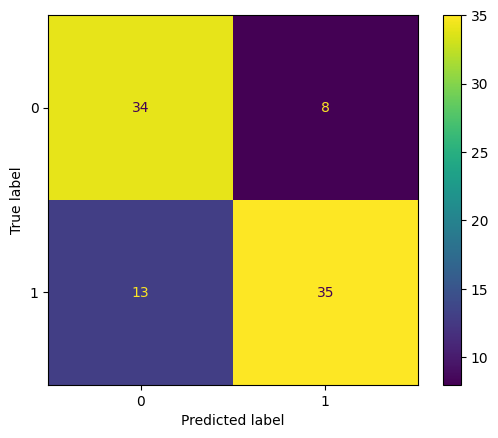

In [22]:
cm = metrics.confusion_matrix(y_test, predictTree)
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()